## Device

In [1]:
shared_folder_Path = "/media/marina/01DB47DC6EBB7DC0/ThreeD/shared"[:-6]
path = '/media/marina/01DB47DC6EBB7DC0/0_Data/conp-dataset/projects/calgary-campinas/CC359/Raw-data/Single-channel/IM_MoCo/'
path_model= '/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/2_stacked/'
import sys,os, glob, torch
import pickle
sys.path.insert(1,shared_folder_Path)
try:
    os.mkdir('')
except:
    pass

paths_train = glob.glob(path + "/train/*")
paths_test  = glob.glob(path + "/test/*")
paths_test_low = [p for p in paths_test if ('motion_5' in p)]
paths_test_mid = [p for p in paths_test if ('motion_15' in p)]
paths_test_hgh = [p for p in paths_test if ('motion_25' in p)]
len(paths_train), len(paths_test_low), len(paths_test_hgh),len(paths_test)

(3, 400, 400, 1200)

## Import

In [2]:
%load_ext autoreload
%autoreload 2

from scipy import ndimage
import torch
from torch.optim import lr_scheduler
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
from tqdm import tqdm
from shared.plot import plot_2_Imgs, plot_3_Imgs, plot_4_Imgs, plot_Img
from shared.ssim import SSIM
ssim_calc = SSIM()


def get_n_params( model):
    pp=0
    for p in list(model.parameters()):
        nn=1
        for s in list(p.size()):
            nn = nn*s
        pp += nn

    return pp


# Deterministic for spectral norm
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

def init_seeds(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(0)
    # no change in alg
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
init_seeds(42)

## Data

In [3]:
from torch.fft import fftn, fftshift, ifftn, ifftshift

def FFT(x):
    return fftshift(fftn(ifftshift(x, dim=(-2, -1)), dim=(-2, -1)), dim=(-2, -1))


def IFFT(x):
    return ifftshift(ifftn(fftshift(x, dim=(-2, -1)), dim=(-2, -1)), dim=(-2, -1))


def norm_0_1(arr):
    arr = ((arr - arr.min()) / (arr.max()-arr.min()))
    return arr
def norm_1_1(arr):
    arr = ((arr - arr.min()) / (arr.max()-arr.min()))*2-1
    return arr


def normImg(x: torch.Tensor):

    # group norm
    c, h, w = x.shape
    x = x.reshape(1, c // 1 * h * w)
  
    mean = x.mean(dim=2).view(1, 1, 1)
    std = x.std(dim=2).view(1, 1, 1)
    x = x.view(c, h, w)
  
  
    return (x - mean) / std, mean, std


def convert_polar_to_cylindrical( magnitude, phase):

    real = magnitude * torch.cos(phase)
    imag = magnitude * torch.sin(phase)
    return real, imag


def convert_cylindrical_to_polar(real,imag):

    mag = (real ** 2 + imag ** 2) ** (0.5)
    phase = torch.atan2(imag, real)
    phase[phase.ne(phase)] = 0.0  # remove NANs if any
    return mag, phase

def normalized_complex_mag(arr):

    mag, phase = convert_cylindrical_to_polar(arr.real,arr.imag)
    normalized_magnitude = (mag - torch.mean(mag)) / (torch.std(mag))
    real,imag = convert_polar_to_cylindrical(normalized_magnitude,phase)
    normed = real+1j*imag 

    return normed


3 1200
BLUR:  tensor([0.4792])


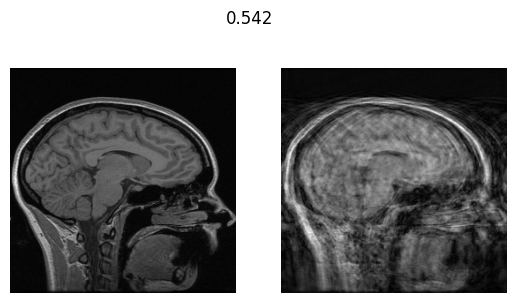

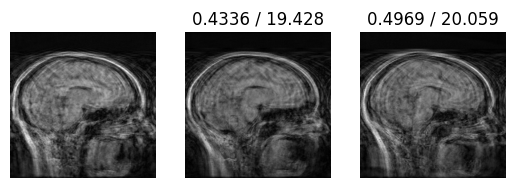

In [4]:
def preprocess(kspace, k_space_artifact,Main_Artifact_path):
    
    # IFFT
    image_Complex = IFFT(kspace)
    image_artifact_Complex = IFFT(k_space_artifact)
    
    # Img
    image = image_Complex.abs()
    image_artifact = image_artifact_Complex.abs()
      
    # prior
    num_diff = 6
    num =  int(Main_Artifact_path[ Main_Artifact_path.find("slice")+num_diff:Main_Artifact_path.find("_motion")])
    path_aft = Main_Artifact_path.replace('slice_' + str(num), 'slice_' +  str(num+1))
    path_bef = Main_Artifact_path.replace('slice_' + str(num),'slice_' + str(num-1))
    
    try:
        bef_art = torch.load(path_bef, weights_only=True)[1]
        bef_art = IFFT(bef_art).abs()
    except:
        bef_art = image_artifact

    try:
        aft_art = torch.load(path_aft, weights_only=True)[1]
        aft_art = IFFT(aft_art).abs()
    except:
        aft_art = image_artifact

    # Norm img
    image = norm_0_1(image)
    image_artifact = norm_0_1(image_artifact)
    bef_art = norm_0_1(bef_art)
    aft_art = norm_0_1(aft_art)

    return  {"Arr":image[None,...],
                "Art":image_artifact[None,...],
             "bef_art":bef_art[None,...],
             "aft_art":aft_art[None,...],
                'path':Main_Artifact_path
            }

class MRIDataset(Dataset):
    def __init__(self, imgs_paths):
        self.imgs_paths = imgs_paths
    
    def __len__(self):
        return len(self.imgs_paths)

    def __getitem__(self, index):

        Main_Artifact_path = self.imgs_paths[index]
        kspace,k_space_artifact,mask = torch.load(Main_Artifact_path, weights_only=False)
        return  preprocess(kspace,k_space_artifact,Main_Artifact_path)
    
#dataset
dataset_train = MRIDataset(paths_train)
dataset_val = MRIDataset(paths_test)
print(len(dataset_train), len(dataset_val))

#dataloaders
batch_size = 1
dataloaders = dict()
dataloaders['train'] = DataLoader(dataset_train, batch_size=batch_size,
                                   shuffle=True, pin_memory=True)
dataloaders['val'] = DataLoader(dataset_val, batch_size=batch_size,
                                shuffle=False, pin_memory=True)
sample = dataset_val[random.randint(0,len(dataset_val))]

device = 'cuda'    
with torch.no_grad():
    Arr = sample['Arr'][None].to(device)
    Art = sample['Art'][None].to(device)
    bef = sample['bef_art'][None].to(device)
    aft = sample['aft_art'][None].to(device)
    plot_2_Imgs(Arr,Art)
    plot_3_Imgs(Art,bef,aft)

## Model

/tmp/ipykernel_5599/2027460914.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC3

4012142
-1034


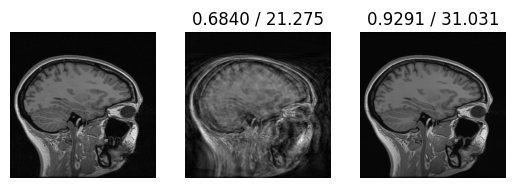

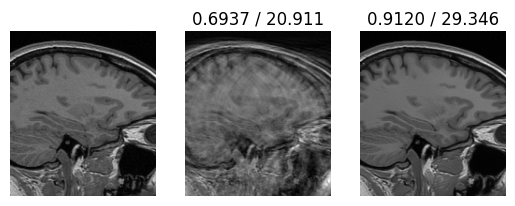

In [5]:
from Correction_Multi_input_pt import *
model = Correction_Multi_input_pt()
model = torch.load('/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/3_stacked/29model.pt','cpu')
print(get_n_params(model))

p = -1034#random.randint(0,len(dataset_val))
print(p)

sample= dataset_val[p]

device = 'cpu'
model = model.to(device)
with torch.no_grad():
    
    Art = sample['Art'][None].to(device)
    bef = sample['bef_art'][None].to(device)
    aft = sample['aft_art'][None].to(device)
    Arr = sample['Arr'][None].to(device)

    Real_out = model(Art, bef,aft)
   
    torch.save(Real_out,'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/Stacked_' + str(p) +'.pt')
    torch.save(Real_out[:,:,30:-63,30:-70],'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/Stacked_sm_' + str(p) +'.pt')
    plot_3_Imgs(sample['Arr'][0],sample['Art'][0],Real_out[0,0])
    plot_3_Imgs(sample['Arr'][:,30:-50,50:-50],sample['Art'][:,30:-50,50:-50],Real_out[:,:,30:-50,50:-50])


## Outer

In [6]:
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)


input_img_3DNuFFT_sub8_run04 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-08/input_img_3DNuFFT_run04.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub8_run04.shape)
input_img_3DNuFFT_sub8_run04 = torch.view_as_complex(input_img_3DNuFFT_sub8_run04)
print(input_img_3DNuFFT_sub8_run04.shape)
input_img_3DNuFFT_sub8_run04 = F.pad( input_img_3DNuFFT_sub8_run04, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub8_run04.shape)

input_img_3DNuFFT_sub8_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-08/input_img_3DNuFFT_run00.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub8_run00.shape)
#input_img_3DNuFFT_sub8_run00 = torch.view_as_complex(input_img_3DNuFFT_sub8_run00)
print(input_img_3DNuFFT_sub8_run00.shape)
input_img_3DNuFFT_sub8_run00 = F.pad( input_img_3DNuFFT_sub8_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub8_run00.shape)


input_img_3DNuFFT_sub1_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-01/sub-01_run-00_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub1_run00.shape)
input_img_3DNuFFT_sub1_run00 = torch.view_as_complex(input_img_3DNuFFT_sub1_run00)
print(input_img_3DNuFFT_sub1_run00.shape)
input_img_3DNuFFT_sub1_run00 = F.pad( input_img_3DNuFFT_sub1_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub1_run00.shape)

input_img_3DNuFFT_sub1_run01 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-01/sub-01_run-02_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub1_run01.shape)
input_img_3DNuFFT_sub1_run01 = torch.view_as_complex(input_img_3DNuFFT_sub1_run01)
print(input_img_3DNuFFT_sub1_run01.shape)
input_img_3DNuFFT_sub1_run01 = F.pad( input_img_3DNuFFT_sub1_run01, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub1_run01.shape)


input_img_3DNuFFT_sub2_run02 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-02_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub2_run02.shape)
input_img_3DNuFFT_sub2_run02 = torch.view_as_complex(input_img_3DNuFFT_sub2_run02)
print(input_img_3DNuFFT_sub2_run02.shape)
input_img_3DNuFFT_sub2_run02 = F.pad( input_img_3DNuFFT_sub2_run02, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub2_run02.shape)


input_img_3DNuFFT_sub2_run01 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-01_imgspace.pt','cpu',weights_only=False)
input_img_3DNuFFT_sub2_run01 = torch.view_as_complex(input_img_3DNuFFT_sub2_run01)
input_img_3DNuFFT_sub2_run01 = F.pad( input_img_3DNuFFT_sub2_run01, (0, 0,0,0, 17, 17), mode='constant', value=0)

input_img_3DNuFFT_sub2_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-00_imgspace.pt','cpu',weights_only=False)
input_img_3DNuFFT_sub2_run00 = torch.view_as_complex(input_img_3DNuFFT_sub2_run00)
input_img_3DNuFFT_sub2_run00 = F.pad( input_img_3DNuFFT_sub2_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)

torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])


105


/tmp/ipykernel_5599/4198580723.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Art = torch.tensor(norm_0_1(Art))


BLUR: 0.521 aes:0.01019


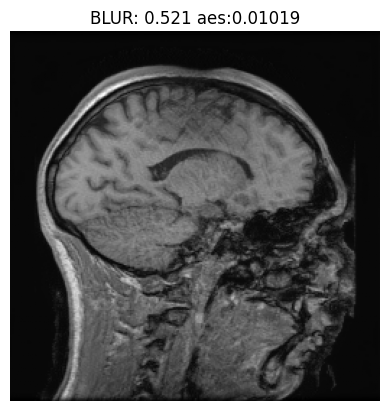

In [8]:
aa = input_img_3DNuFFT_sub2_run02
with torch.no_grad():
    t = 105#t+5
    print(t)

    Art = (aa[:,t])
    Art = torch.tensor(ndimage.rotate(Art, -90))
    Art = abs(Art)[None][None]#.cuda()
    Art = torch.tensor(norm_0_1(Art))

    bef = (aa[:,t-1])
    bef = torch.tensor(ndimage.rotate(bef, -90))
    bef = abs(bef)[None][None]
    bef = norm_0_1(bef)#.cuda()

    aft = (aa[:,t+1])
    aft = torch.tensor(ndimage.rotate(aft, -90))
    aft = abs(aft)[None][None]
    aft = norm_0_1(aft)#.cuda()

    Real_out = model(Art, bef,aft)
plot_Img(Real_out)

In [8]:
with torch.no_grad():
    OUTs = []
    aa = input_img_3DNuFFT_sub2_run02

    for t in tqdm(range(40,200)):

        Art = (aa[:,t])
        Art = torch.tensor(ndimage.rotate(Art, -90))
        Art = abs(Art)[None][None]#.cuda()
        Art = torch.tensor(norm_0_1(Art))

        bef = (aa[:,t-1])
        bef = torch.tensor(ndimage.rotate(bef, -90))
        bef = abs(bef)[None][None]
        bef = norm_0_1(bef)#.cuda()

        aft = (aa[:,t+1])
        aft = torch.tensor(ndimage.rotate(aft, -90))
        aft = abs(aft)[None][None]
        aft = norm_0_1(aft)#.cuda()

        Real_out = model(Art, bef,aft)

        OUTs.append(Real_out[0,0].cpu().detach())

  0%|          | 0/160 [00:00<?, ?it/s]/tmp/ipykernel_5994/1660188028.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Art = torch.tensor(norm_0_1(Art))
100%|██████████| 160/160 [01:32<00:00,  1.72it/s]


torch.Size([160, 256, 256])
torch.Size([180, 160])
torch.Size([180, 160])
BLUR:  tensor([0.5419])


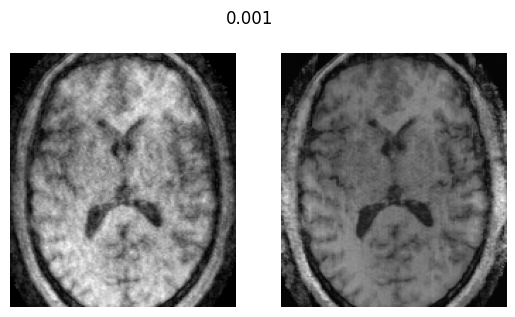

In [9]:
t = 100#t+10

OUT_tensor = torch.stack(OUTs)
print(OUT_tensor.shape)
OUT_tensor = abs(torch.tensor(ndimage.rotate(OUT_tensor[:,t], 90)))[40:220]
print(OUT_tensor.shape)

aa_part = abs(aa[40:220,40:200,t])
print(aa_part.shape)

plot_2_Imgs(aa_part,OUT_tensor)

## Loss & Optimization

In [ ]:
from shared.GradualWarmupSchedulerFile import *
from shared.ssim import SSIM
import torch.nn as nn

SSIM_criterion = SSIM().cuda()
msee = nn.MSELoss()
learning_rate = 10**-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

## Training

In [ ]:
num_epochs = 50

for epoch in range( num_epochs):
    model.train()
    ssim_all = 0
    pbar_train = tqdm(enumerate(dataloaders['train']), total=len(dataloaders['train']), position=0, leave=True)
    for (i, data) in pbar_train:

        optimizer.zero_grad()

        Art = Variable(data['Art']).to(device)
        bef = Variable(data['bef_art']).to(device)
        aft = Variable(data['aft_art']).to(device)
        Arr = Variable(data['Arr'].to(device))
        
        outputs_train = model(Art, bef, aft)

        loss_train = 1-SSIM_criterion(outputs_train, Arr)
        loss_train.backward()
        optimizer.step()


        ssim_all += float(SSIM_criterion(outputs_train, Arr).cpu().detach())

        if(i%10==0):
            if((i==0) and (epoch==0)):
                file1 = open(path_model + "log.txt", "w")
            else:
                file1 = open(path_model + "log.txt", "a")
            file1.write("Epoch: " + str(epoch)+ "  , step: " + str(i) + "  , SSIM: " + str(float(ssim_all/(i+1))) + "\n")
            file1.close()



    print("Train SSIM: " ,ssim_all/len(pbar_train))
    print( "epoch: " , epoch, 'lr: '+ str(optimizer.param_groups[0]['lr'])+ "\n")

    file1 = open(path_model + "log.txt", "a")
    file1.write("Epoch: " + str(epoch)+ "  , Train: " + "  , SSIM: " + str(float(ssim_all/len(pbar_train))) + "\n"+ 'lr: '+ str(optimizer.param_groups[0]['lr'])+ "\n")
    file1.close()

    torch.save(model, path_model+"/"+str(epoch)+"model.pt")


    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`
    with torch.no_grad():
      ssim_all = 0
      pbar_test = tqdm(enumerate(dataloaders['val']), total=len(dataloaders['val']), position=0, leave=True)
      for (i, datatest) in pbar_test:

            Art = Variable(datatest['Art']).to(device)
            bef = Variable(datatest['bef_art']).to(device)
            aft = Variable(datatest['aft_art']).to(device)
            Arr = Variable(datatest['Arr'].to(device))

            outputs_test = model(Art, bef, aft)

            ssim_all +=  float(SSIM_criterion(outputs_test, Arr).cpu().detach())

      print("Test SSIM: " ,ssim_all/len(pbar_test))

      file1 = open(path_model + "log.txt", "a")
      file1.write("Epoch: " + str(epoch)+ "  , Test: " + "  , SSIM: " + str(float(ssim_all/len(pbar_test))) + "\n")
      file1.close()


100%|██████████| 3/3 [00:01<00:00,  2.26it/s]


Train SSIM:  -0.02488720106581847
epoch:  0 lr: 0.0001



  2%|▏         | 22/1200 [00:03<03:11,  6.14it/s]


KeyboardInterrupt: 

In [ ]:
from torcheval.metrics import PeakSignalNoiseRatio
metric = PeakSignalNoiseRatio()
from shared.ssim import SSIM
SSIM_criterion = SSIM().cuda()
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)
from shared.mutualInfo import mutual_information
import time

In [ ]:
from torcheval.metrics import PeakSignalNoiseRatio
metric = PeakSignalNoiseRatio()
from shared.ssim import SSIM
SSIM_criterion = SSIM().cuda()
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)
times = []

with torch.no_grad():
  ssim_all = [] ; psnr_bef=[] ; ssim_all_bef = []
  psnr=[] ; BLUR = [] ; BLUR_BEF = []
  MI = [] ; MI_BEF = []   
  pbar_test = tqdm(enumerate(dataloaders['val']), total=len(dataloaders['val']), position=0, leave=True)
  for (i, datatest) in pbar_test:

        path_ = (datatest['path'])[0]
        Arr = Variable(datatest['Arr']).to(device)
        Art = Variable(datatest['Art']).to(device)
        bef = Variable(datatest['bef_art']).to(device)
        aft = Variable(datatest['aft_art']).to(device)

        a = time.time()
        outputs_test = model(Art, bef, aft)
        times.append(time.time()-a)

        ssim_all .append(  float(SSIM_criterion(outputs_test, Arr).cpu().detach()))
        ssim_all_bef .append( float(SSIM_criterion(Art, Arr).cpu().detach()))

        metric = PeakSignalNoiseRatio()
        metric.update(outputs_test, Arr)
        paft = float(metric.compute())
        psnr.append( paft)

        metric = PeakSignalNoiseRatio()
        metric.update(Art, Arr)
        pbef = float(metric.compute())
        psnr_bef.append( pbef)

        BLUR .append( torch.sum(b(outputs_test)).cpu().detach())
        BLUR_BEF  .append( torch.sum(b(Art)).cpu().detach())


        MI .append( mutual_information(Arr,outputs_test))
        MI_BEF .append( mutual_information(Arr,Art))

        # save
        if(i==0):do='w'
        else: do = 'a'
        p = '/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/3_stacked/data/'
      
        with open(p+ 'ssim_all.txt', do) as f:
            f.write( str(float(SSIM_criterion(outputs_test, Arr).cpu().detach())) + "\n" )
        with open(p+ 'ssim_all_bef.txt', do) as f:
            f.write( str(float(SSIM_criterion(Art, Arr).cpu().detach())) + "\n" )

        with open(p+ 'psnr_all.txt', do) as f:
            f.write( str(paft) + "\n" )
        with open(p+ 'psnr_all_bef.txt', do) as f:
            f.write( str(pbef) + "\n" )

        with open(p+ 'blur_all.txt', do) as f:
            f.write( str(float(torch.sum(b(outputs_test)).cpu().detach()))  + "\n" )
        with open(p+ 'blur_all_bef.txt', do) as f:
            f.write( str(float(torch.sum(b(Art)).cpu().detach())) + "\n" )
        
        with open(p+ 'MI_all.txt', do) as f:
            f.write( str(float(mutual_information(Arr,outputs_test)))  + "\n" )
        with open(p+ 'MI_all_bef.txt', do) as f:
            f.write( str(float(mutual_information(Arr,Art))) + "\n" )
        
        with open(p+ 'path.txt', do) as f:
            f.write( path_ + "\n" )

100%|██████████| 1200/1200 [05:19<00:00,  3.76it/s]


In [ ]:
print("ssim aft std :",np.std(ssim_all), "ssim mean :",np.mean(ssim_all))
print("ssim bef std :",np.std(ssim_all_bef), "ssim mean :",np.mean(ssim_all_bef) ,"\n")

print("psnr aft std :",np.std(psnr), "psnr mean :",np.mean(psnr))
print("psnr bef std :",np.std(psnr_bef), "psnr mean :",np.mean(psnr_bef),"\n")

print("Blur aft std :",np.std(BLUR), "Blur mean :",np.mean(BLUR))
print("Blur bef std :",np.std(BLUR_BEF), "Blur mean :",np.mean(BLUR_BEF),"\n")

print("MI aft std :",np.std(MI), "MI mean :",np.mean(MI))
print("MI bef std :",np.std(MI_BEF), "MI mean :",np.mean(MI_BEF),"\n")

print("time std :",np.std(times), "MI mean :",np.mean(times),"\n")

ssim aft std : 0.03657769052889876 ssim mean : 0.9263415480156739
ssim bef std : 0.12453755104871833 ssim mean : 0.7658770545820395 

psnr aft std : 2.4288152728540497 psnr mean : 31.190008101463317
psnr bef std : 5.026714467870823 psnr mean : 25.071650342941282 

Blur aft std : 0.027209587 Blur mean : 0.42321837
Blur bef std : 0.021324178 Blur mean : 0.44909087 

MI aft std : 0.14882937366348656 MI mean : 1.2824270489910778
MI bef std : 0.2738904738789271 MI mean : 1.003781371839761 

time std : 0.011301534000010311 MI mean : 0.03992561201254527 

